In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import random, os
import warnings
warnings.filterwarnings("ignore")
tf.get_logger().setLevel("ERROR")

In [99]:
# Load dataset, data_gen.py can be used to genreate the xauusd_macro.csv file if you don't have it
df = pd.read_csv("xauusd_macro.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)
print(f"Loaded {len(df)} rows | {df['Date'].iloc[0].date()} → {df['Date'].iloc[-1].date()}")


Loaded 4041 rows | 2010-01-04 → 2026-01-30


In [100]:
# Helper functions to calcuate rsi, atr, macd indicators
def rsi(s, w=14):
    d = s.diff()
    g = d.clip(lower=0).ewm(alpha=1/w, adjust=False).mean()
    l = (-d).clip(lower=0).ewm(alpha=1/w, adjust=False).mean()
    return 100 - (100 / (1 + g / l.replace(0, np.nan)))

def atr(h, l, c, w=14):
    pc = c.shift(1)
    tr = pd.concat([h-l, (h-pc).abs(), (l-pc).abs()], axis=1).max(axis=1)
    return tr.ewm(alpha=1/w, adjust=False).mean()

def macd_hist(c, f=12, s=26, sig=9):
    line = c.ewm(span=f, adjust=False).mean() - c.ewm(span=s, adjust=False).mean()
    return line - line.ewm(span=sig, adjust=False).mean()

In [101]:
# Builds features for the model, including original 10 features and new macro features
def build_features(df):
    d = df.copy()
    c, h, l = d["Close"], d["High"], d["Low"]
    dxy, vix, oil = d["DXY_Close"], d["VIX_Close"], d["Oil_Close"]
    ret1 = c.pct_change()

    # original 10 features 
    d["macd_hist"]     = macd_hist(c) / c
    d["rsi_14"]        = rsi(c)
    d["atr_pct"]       = atr(h, l, c) / c
    d["ret_5"]         = c.pct_change(5)
    d["ret_21"]        = c.pct_change(21)
    d["vol_ratio"]     = ret1.rolling(5).std() / ret1.rolling(21).std().replace(0, np.nan)
    d["dxy_ret5"]      = dxy.pct_change(5)
    d["vix_chg"]       = vix.diff()
    d["oil_ret5"]      = oil.pct_change(5)
    d["gold_dxy_corr"] = ret1.rolling(21).corr(dxy.pct_change())

    # NEW: macro features from xauusd_macro.csv 
    # These columns already exist in the CSV — we just need to
    # compute changes and normalise where needed

    # Real yield momentum (most important gold driver)
    d["real_yield_chg"]    = d["real_yield_10y"].diff()
    d["real_yield_5d_chg"] = d["real_yield_10y"].diff(5)

    # Breakeven inflation change
    d["breakeven_chg"]     = d["breakeven_10y"].diff()

    # High yield spread change (risk appetite)
    d["hy_spread_chg"]     = d["hy_spread"].diff()

    # Rate change direction ( had some issues in calcuating this, we will fix it later on)
    # d["rate_change"]       = d["fed_funds_rate"].diff().fillna(0)

    # GPR normalised (z-score over rolling 63 days)
    if "gpr_index" in d.columns:
        gpr_mean = d["gpr_index"].rolling(63).mean()
        gpr_std  = d["gpr_index"].rolling(63).std().replace(0, np.nan)
        d["gpr_zscore"] = (d["gpr_index"] - gpr_mean) / gpr_std
    else:
        d["gpr_zscore"] = 0.0

    return d

df = build_features(df)

In [102]:
FEATURES = [
    # Original 10 — keep all of these
    "macd_hist", 
    "rsi_14", 
    "atr_pct", 
    "ret_5", 
    "ret_21",
    "vol_ratio", 
    "dxy_ret5", 
    "vix_chg", 
    "oil_ret5", 
    "gold_dxy_corr",

    # Macro — changes and flags only (no levels)
    "real_yield_chg",
    "real_yield_5d_chg",
    "breakeven_chg",
    "hy_spread_chg",
    "fomc_week",
    "macro_event_week",
    "gpr_zscore",

    # # Real yield — strongest structural gold driver
    # # "real_yield_10y",       # level
    # "real_yield_chg",       # 1-day change
    # "real_yield_5d_chg",    # 5-day momentum

    # # Inflation expectations
    # "breakeven_10y",        # level
    # "breakeven_chg",        # 1-day change

    # # Fed / rates
    # # "fed_funds_rate",        # current rate level
    # # "rate_change",          # rate hike/cut signal

    # # Risk appetite
    # "hy_spread_chg",        # high yield spread change

    # # Event flags — binary signals
    # "fomc_week",            # 1 if within 3 days of FOMC
    # "days_to_fomc",         # countdown to next meeting
    # "days_to_cpi",          # countdown to next CPI
    # "days_to_nfp",          # countdown to next NFP
    # "macro_event_week",     # 1 if any major event within 3 days

    # # Geopolitical risk
    # "gpr_zscore",           # normalised GPR (z-score vs recent history)
]

In [6]:
# how can i see the features important for the model?

In [103]:
FWD      = 5
LOOKBACK = 15

# 4. Labelling — top/bottom 30% quantile(can be adjusted to 40/60 for more balanced classes)
df["fwd_ret_5"] = df["Close"].shift(-FWD) / df["Close"] - 1
q_lo = df["fwd_ret_5"].quantile(0.30)
q_hi = df["fwd_ret_5"].quantile(0.70)
df["label"] = np.nan
df.loc[df["fwd_ret_5"] >= q_hi, "label"] = 1
df.loc[df["fwd_ret_5"] <= q_lo, "label"] = 0

# MIN_RET = 0.008   # minimum 0.8% move to be labeled so that to handle netural days
# q_lo = df["fwd_ret_5"].quantile(0.30)   # tighter: was 0.30
# q_hi = df["fwd_ret_5"].quantile(0.70)   # tighter: was 0.70
# df["label"] = np.nan
# df.loc[(df["fwd_ret_5"] >= q_hi) & (df["fwd_ret_5"] >  MIN_RET), "label"] = 1
# df.loc[(df["fwd_ret_5"] <= q_lo) & (df["fwd_ret_5"] < -MIN_RET), "label"] = 0

df_clean = df.dropna(subset=FEATURES + ["label"]).reset_index(drop=True)

# filter only after 2025-08-01 to focus on recent data
# df_clean = df_clean[df_clean["Date"] < "2025-08-01"].reset_index(drop=True)

print(f"Rows after dropna: {len(df_clean)}")
print(f"Date range: {df_clean['Date'].iloc[0].date()} → {df_clean['Date'].iloc[-1].date()}")


Rows after dropna: 2407
Date range: 2010-02-03 → 2026-01-23


In [104]:
TRAIN_END = "2022-12-31"   # train includes 2022 rate hike peak
VAL_END   = "2024-03-31" 

tr = df_clean[df_clean["Date"] <= TRAIN_END]
va = df_clean[(df_clean["Date"] > TRAIN_END) & (df_clean["Date"] <= VAL_END)]
te = df_clean[df_clean["Date"] > VAL_END].copy()

sc    = StandardScaler()
Xtr   = sc.fit_transform(tr[FEATURES])
Xva   = sc.transform(va[FEATURES])
Xte   = sc.transform(te[FEATURES])
ytr   = tr["label"].astype(int).values
yva   = va["label"].astype(int).values
yte   = te["label"].astype(int).values

def make_seq(X, y, lb):
    Xs, ys = [], []
    for i in range(lb, len(X)):
        Xs.append(X[i-lb:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

Xtr_s, ytr_s = make_seq(Xtr, ytr, LOOKBACK)
Xva_s, yva_s = make_seq(Xva, yva, LOOKBACK)
Xte_s, yte_s = make_seq(Xte, yte, LOOKBACK)

In [105]:

def set_seeds(seed=24):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    # Forces TF to use deterministic ops (slight performance cost)
    os.environ["TF_DETERMINISTIC_OPS"] = "1"

set_seeds(44)

# 6. Train model
print("Training LSTM...")
cw = compute_class_weight("balanced", classes=np.array([0,1]), y=ytr_s)

model = models.Sequential([
    layers.Input(shape=(LOOKBACK, len(FEATURES))),
    layers.LSTM(24),
    layers.Dropout(0.2),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model.compile(optimizer=tf.keras.optimizers.Adam(5e-4),
              loss="binary_crossentropy", metrics=["accuracy"])
model.fit(Xtr_s, ytr_s,
          validation_data=(Xva_s, yva_s),
          epochs=80, batch_size=32,
          shuffle = False,
          class_weight={0: cw[0], 1: cw[1]},
          callbacks=[
              callbacks.EarlyStopping(monitor="val_loss", patience=10,
                                      restore_best_weights=True, verbose=0),
              callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                          patience=5, verbose=0),
          ], verbose=0)
print("Training done.")

# check MSE accuracy precision recall
loss, acc = model.evaluate(Xva_s, yva_s, verbose=0)
print(f"Validation Accuracy: {acc:.4f}")    


Training LSTM...
Training done.
Validation Accuracy: 0.4639


In [106]:
# Metrics: Accuracy, MSE, Precision, Recall, F1
from sklearn.metrics import accuracy_score, mean_squared_error, precision_score, recall_score, f1_score

prob = model.predict(Xte_s, verbose=0).flatten()

# Validation predictions
val_prob = model.predict(Xva_s, verbose=0).flatten()
val_pred = (val_prob >= 0.5).astype(int)

# Test predictions (already computed as `prob`)
test_prob = prob
test_pred = (test_prob >= 0.5).astype(int)

print("=== Validation Metrics ===")
print(f"Accuracy : {accuracy_score(yva_s, val_pred):.4f}")
print(f"MSE(prob): {mean_squared_error(yva_s, val_prob):.4f}")
print(f"MSE(pred): {mean_squared_error(yva_s, val_pred):.4f}")
print(f"Precision: {precision_score(yva_s, val_pred, zero_division=0):.4f}")
print(f"Recall   : {recall_score(yva_s, val_pred, zero_division=0):.4f}")
print(f"F1-score : {f1_score(yva_s, val_pred, zero_division=0):.4f}")

print("\n=== Test Metrics ===")
print(f"Accuracy : {accuracy_score(yte_s, test_pred):.4f}")
print(f"MSE(prob): {mean_squared_error(yte_s, test_prob):.4f}")
print(f"MSE(pred): {mean_squared_error(yte_s, test_pred):.4f}")
print(f"Precision: {precision_score(yte_s, test_pred, zero_division=0):.4f}")
print(f"Recall   : {recall_score(yte_s, test_pred, zero_division=0):.4f}")
print(f"F1-score : {f1_score(yte_s, test_pred, zero_division=0):.4f}")

=== Validation Metrics ===
Accuracy : 0.4639
MSE(prob): 0.2515
MSE(pred): 0.5361
Precision: 0.4563
Recall   : 0.5875
F1-score : 0.5137

=== Test Metrics ===
Accuracy : 0.6298
MSE(prob): 0.2396
MSE(pred): 0.3702
Precision: 0.6824
Recall   : 0.8281
F1-score : 0.7482


In [108]:
# Remaning section contains backtesting the model with a simple strategy and plotting the equity curve and other insights. 
# This doesn't mean the model is profitable in real life as we haven't considered transaction costs, slippage, risk management, entry strategy, etc. But it can give us some insights on how the model's predictions would have performed historically.

# 7. BUILD SIGNAL DATAFRAME
#    Each row = one trade signal on that date
test_dates  = te["Date"].values[LOOKBACK:]
test_close  = te["Close"].values[LOOKBACK:]
test_fwd    = te["fwd_ret_5"].values[LOOKBACK:]
test_true   = yte_s

signal_df = pd.DataFrame({
    "Date":       test_dates,
    "Close":      test_close,
    "prob_up":    prob,
    "signal":     np.where(prob >= 0.5, 1, -1),   # 1=Long, -1=Short
    "true_label": test_true,
    "fwd_ret_5":  test_fwd,
})
signal_df["Date"] = pd.to_datetime(signal_df["Date"])

# def is_trending(df, lookback=20, threshold=0.3):
#     return df["vol_ratio"].rolling(lookback).mean() > threshold


# signal_df = pd.DataFrame({
#     "Date": test_dates,
#     "Close": test_close,
#     "prob_up": prob,
#     "signal": np.where(prob >= 0.5, 1, -1),
#     "true_label": test_true,
#     "fwd_ret_5": test_fwd,
# })

# # ADD THIS — attach regime info to each signal row
# signal_df["is_trending"] = is_trending(signal_df, lookback=20, threshold=0.3).values

In [ ]:
# 8. BACKTEST ENGINE
#  Rules:
#  - Hold each position for exactly FWD=5 days
#  - Only one position at a time (no overlapping trades)
#  - Entry at Close on signal day
#  - Exit at Close 5 days later
#  - Transaction cost = spread (adjustable)
#  - Position size = fixed fraction of equity

INITIAL_CAPITAL   = 100_000     # USD
POSITION_SIZE_PCT = 1.00       # risk 10% of equity per trade
SPREAD_PCT        = 0.0002     # 0.02% round-trip spread (realistic for XAUUSD)
CONF_THRESHOLD    = 0.35   # only trade on more confident predictions
STOP_LOSS_PCT     = 0.015  # 1.5% stop loss - can be adjusted

def run_backtest(signal_df, initial_capital, pos_size_pct,
                 spread_pct, conf_threshold, stop_loss_pct, label="Strategy"):
    """
    Stop-loss logic:
      - We don't have intraday data, so we simulate stop on daily closes.
      - For each trade day between entry and exit, if the daily close
        moves more than stop_loss_pct against the position, we exit early
        using that day's close as the exit price.
      - This is conservative (real stops would trigger intraday).
    """
    equity       = initial_capital
    equity_curve = [equity]
    dates_curve  = [signal_df["Date"].iloc[0]]
    trades       = []
    i            = 0

    # Merge close prices back by date for stop-loss checking
    close_by_date = signal_df.set_index("Date")["Close"]

    while i < len(signal_df):
        row = signal_df.iloc[i]

        # Skip if not confident enough
        confident = (row["prob_up"] >= conf_threshold) or \
                    (row["prob_up"] <= (1 - conf_threshold))
        if not confident:
            i += 1
            equity_curve.append(equity)
            dates_curve.append(row["Date"])
            continue

        direction   = 1 if row["prob_up"] >= 0.5 else -1
        entry_price = row["Close"]
        entry_date  = row["Date"]

        # Check stop loss on each day until exit
        stopped_out = False
        exit_price  = entry_price * (1 + row["fwd_ret_5"])   # default: full hold
        exit_date   = entry_date + pd.Timedelta(days=FWD)

        # Look at closes over the next FWD days in signal_df
        future = signal_df.iloc[i+1 : i+FWD+1]
        for _, frow in future.iterrows():
            daily_move = direction * (frow["Close"] / entry_price - 1)
            if daily_move <= -stop_loss_pct:
                # Stop triggered — exit at this day's close
                exit_price  = frow["Close"]
                exit_date   = frow["Date"]
                stopped_out = True
                break

        position_value = equity * pos_size_pct
        gross_ret      = direction * (exit_price / entry_price - 1)
        net_ret        = gross_ret - spread_pct
        pnl            = position_value * net_ret
        equity        += pnl

        trades.append({
            "entry_date":   entry_date,
            "exit_date":    exit_date,
            "direction":    "Long" if direction == 1 else "Short",
            "entry_price":  round(entry_price, 2),
            "exit_price":   round(exit_price, 2),
            "gross_ret":    round(gross_ret * 100, 3),
            "net_ret":      round(net_ret * 100, 3),
            "pnl":          round(pnl, 2),
            "equity":       round(equity, 2),
            "win":          pnl > 0,
            "stopped_out":  stopped_out,
        })

        i += FWD
        equity_curve.append(equity)
        dates_curve.append(row["Date"])

    trades_df = pd.DataFrame(trades)
    eq_df     = pd.DataFrame({"Date": dates_curve, "Equity": equity_curve})
    return trades_df, eq_df

In [110]:
# 9. Run Backtest
trades_df, eq_df = run_backtest(
    signal_df, INITIAL_CAPITAL, POSITION_SIZE_PCT,
    SPREAD_PCT, CONF_THRESHOLD, STOP_LOSS_PCT, "LSTM Strategy"
)

# Buy-and-hold benchmark for comparison
bh_ret    = (signal_df["Close"].iloc[-1] / signal_df["Close"].iloc[0]) - 1
bh_equity = INITIAL_CAPITAL * (1 + bh_ret * POSITION_SIZE_PCT)

# bh_equity = INITIAL_CAPITAL * (1 + bh_ret)

In [120]:
# 10. Performance Metrics
def calc_performance(trades_df, eq_df, initial_capital):
    if len(trades_df) == 0:
        print("No trades executed.")
        return

    final_eq      = eq_df["Equity"].iloc[-1]
    total_return  = (final_eq - initial_capital) / initial_capital * 100
    wins          = trades_df["win"].sum()
    losses        = (~trades_df["win"]).sum()
    win_rate      = wins / len(trades_df) * 100
    avg_win       = trades_df.loc[trades_df["win"],  "net_ret"].mean()
    avg_loss      = trades_df.loc[~trades_df["win"], "net_ret"].mean()
    profit_factor = (trades_df.loc[trades_df["win"],  "pnl"].sum() /
                     abs(trades_df.loc[~trades_df["win"], "pnl"].sum())
                     if losses > 0 else np.inf)

    # Drawdown
    eq_series  = eq_df["Equity"]
    roll_max   = eq_series.cummax()
    drawdown   = (eq_series - roll_max) / roll_max * 100
    max_dd     = drawdown.min()

    # Annualized return (approximate)
    n_days     = (eq_df["Date"].iloc[-1] - eq_df["Date"].iloc[0]).days
    ann_return = ((final_eq / initial_capital) ** (365 / max(n_days, 1)) - 1) * 100

    # Sharpe (simplified — using trade returns)
    trade_rets = trades_df["net_ret"].values / 100
    sharpe     = (trade_rets.mean() / trade_rets.std() * np.sqrt(252 / FWD)
                  if trade_rets.std() > 0 else 0)

    print("\n" + "="*55)
    print("BACKTEST PERFORMANCE REPORT")
    print("="*55)
    print(f"\n  {'Initial Capital':<30} ${initial_capital:>10,.2f}")
    print(f"  {'Final Equity':<30} ${final_eq:>10,.2f}")
    print(f"  {'Total Return':<30} {total_return:>+10.2f}%")
    print(f"  {'Annualized Return':<30} {ann_return:>+10.2f}%")
    print(f"\n  {'Total Trades':<30} {len(trades_df):>10}")
    print(f"  {'Wins':<30} {wins:>10}")
    print(f"  {'Losses':<30} {losses:>10}")
    print(f"  {'Win Rate':<30} {win_rate:>10.1f}%")
    print(f"  {'Avg Win':<30} {avg_win:>+10.3f}%")
    print(f"  {'Avg Loss':<30} {avg_loss:>+10.3f}%")
    print(f"  {'Profit Factor':<30} {profit_factor:>10.2f}")
    print(f"  {'Max Drawdown':<30} {max_dd:>10.2f}%")
    print(f"  {'Sharpe Ratio':<30} {sharpe:>10.2f}")
    print(f"\n  {'Spread cost per trade':<30} {SPREAD_PCT*100:>10.3f}%")
    print(f"  {'Position size':<30} {POSITION_SIZE_PCT*100:>10.0f}% of equity")
    print(f"  {'Hold period':<30} {FWD:>10} days")

    print(f"\n  {'Buy & Hold return (same size)':<30} {(bh_equity-initial_capital)/initial_capital*100:>+10.2f}%")

    return {
        "total_return": total_return,
        "win_rate": win_rate,
        "max_dd": max_dd,
        "sharpe": sharpe,
        "profit_factor": profit_factor,
    }

perf = calc_performance(trades_df, eq_df, INITIAL_CAPITAL)

# Show last 10 trades
print("\nLast 10 trades:")
print(trades_df[["entry_date","direction","entry_price","exit_price",
                  "gross_ret","net_ret","pnl","equity"]].tail(10).to_string(index=False))



BACKTEST PERFORMANCE REPORT

  Initial Capital                $100,000.00
  Final Equity                   $101,224.33
  Total Return                        +1.22%
  Annualized Return                   +0.70%

  Total Trades                            3
  Wins                                    2
  Losses                                  1
  Win Rate                             66.7%
  Avg Win                            +2.455%
  Avg Loss                           -3.568%
  Profit Factor                        1.34
  Max Drawdown                        -3.57%
  Sharpe Ratio                         1.11

  Spread cost per trade               0.020%
  Position size                         100% of equity
  Hold period                             5 days

  Buy & Hold return (same size)     +114.08%

Last 10 trades:
entry_date direction  entry_price  exit_price  gross_ret  net_ret      pnl    equity
2025-03-31      Long       3122.8      3012.0     -3.548   -3.568 -3568.10  96431.90
2025-0

In [119]:
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score, precision_score, recall_score

SEEDS = [42, 7, 123, 0, 99]
results = []



for seed in SEEDS:
    # Set seeds
    set_seeds(seed)
    
    # Rebuild model
    model = models.Sequential([
        layers.Input(shape=(LOOKBACK, len(FEATURES))),
        layers.LSTM(24),
        layers.Dropout(0.4),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(5e-4),
                  loss="binary_crossentropy", metrics=["accuracy"])
    
    cw = compute_class_weight("balanced", classes=np.array([0,1]), y=ytr_s)
    
    model.fit(Xtr_s, ytr_s,
              validation_data=(Xva_s, yva_s),
              epochs=80, batch_size=32,
              shuffle=False,
              class_weight={0: cw[0], 1: cw[1]},
              callbacks=[
                  callbacks.EarlyStopping(monitor="val_loss", patience=10,
                                          restore_best_weights=True, verbose=0),
                  callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                              patience=5, verbose=0),
              ], verbose=0)
    
    # Evaluate on TEST set (not validation)
    y_prob = model.predict(Xte_s, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)
    
    results.append({
        "seed":      seed,
        "accuracy":  accuracy_score(yte_s, y_pred),
        "precision": precision_score(yte_s, y_pred, zero_division=0),
        "recall":    recall_score(yte_s, y_pred, zero_division=0),
        "f1":        f1_score(yte_s, y_pred, zero_division=0),
        "auc":       roc_auc_score(yte_s, y_prob),
    })
    print(f"Seed {seed:>3} done — F1: {results[-1]['f1']:.4f}, AUC: {results[-1]['auc']:.4f}")

# Summary
df = pd.DataFrame(results).set_index("seed")
print("\n--- Per-seed results ---")
print(df.round(4).to_string())

print("\n--- Mean ± Std across seeds ---")
summary = pd.DataFrame({"mean": df.mean(), "std": df.std()})
for metric, row in summary.iterrows():
    print(f"  {metric:<10} {row['mean']:.4f} ± {row['std']:.4f}")

Seed  42 done — F1: 0.6324, AUC: 0.4702
Seed   7 done — F1: 0.3446, AUC: 0.5264
Seed 123 done — F1: 0.5994, AUC: 0.5395
Seed   0 done — F1: 0.4706, AUC: 0.6008
Seed  99 done — F1: 0.6544, AUC: 0.5299

--- Per-seed results ---
      accuracy  precision  recall      f1     auc
seed                                             
42      0.5294     0.6573  0.6094  0.6324  0.4702
7       0.3945     0.6133  0.2396  0.3446  0.5264
123     0.5329     0.6966  0.5260  0.5994  0.5395
0       0.5017     0.8000  0.3333  0.4706  0.6008
99      0.5467     0.6631  0.6458  0.6544  0.5299

--- Mean ± Std across seeds ---
  accuracy   0.5010 ± 0.0618
  precision  0.6861 ± 0.0702
  recall     0.4708 ± 0.1770
  f1         0.5403 ± 0.1305
  auc        0.5334 ± 0.0465


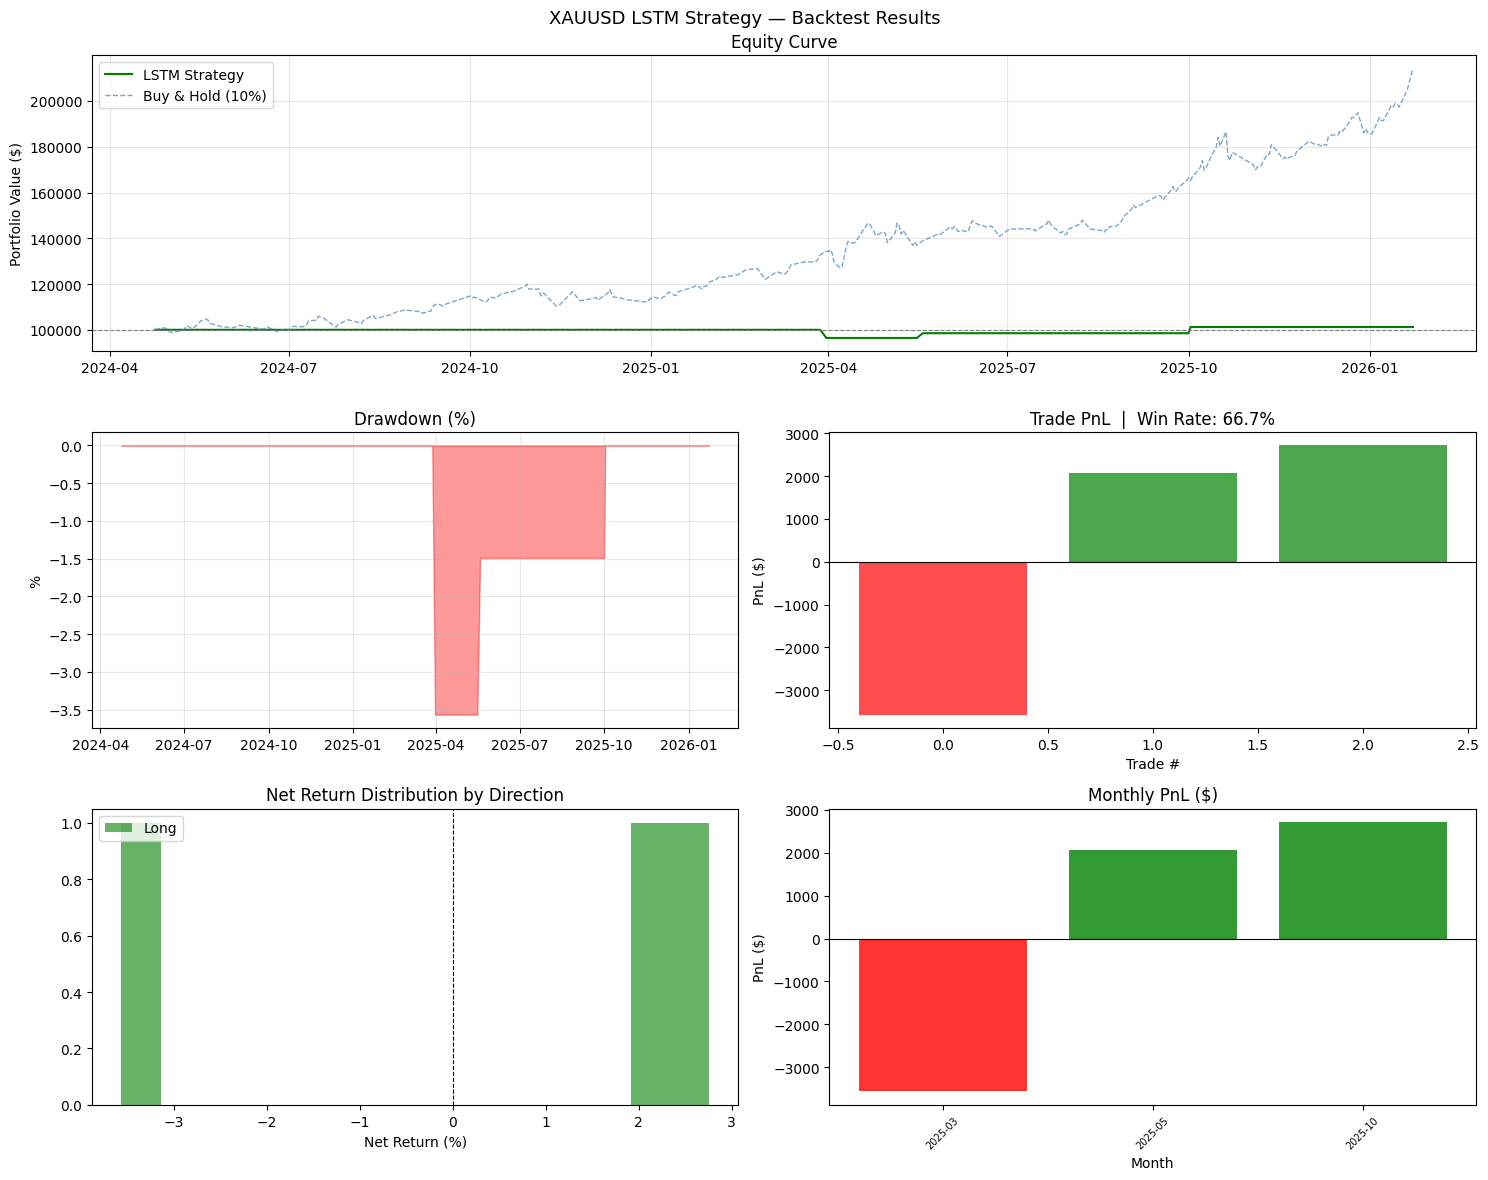

In [121]:
# 11. Plots
fig = plt.figure(figsize=(15, 12))
gs  = gridspec.GridSpec(3, 2, figure=fig)
fig.suptitle("XAUUSD LSTM Strategy — Backtest Results", fontsize=13)

# Equity curve
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(eq_df["Date"], eq_df["Equity"], color="green",
         linewidth=1.5, label="LSTM Strategy")
ax1.axhline(INITIAL_CAPITAL, color="gray", linestyle="--", linewidth=0.8)
# Mark buy and hold
bh_curve = INITIAL_CAPITAL + (signal_df["Close"] / signal_df["Close"].iloc[0] - 1) * INITIAL_CAPITAL * POSITION_SIZE_PCT
ax1.plot(signal_df["Date"], bh_curve, color="steelblue",
         linewidth=1.0, linestyle="--", alpha=0.7, label="Buy & Hold (10%)")
ax1.set_title("Equity Curve")
ax1.set_ylabel("Portfolio Value ($)")
ax1.legend()
ax1.grid(alpha=0.3)

# Drawdown
ax2 = fig.add_subplot(gs[1, 0])
eq_series = eq_df["Equity"]
roll_max  = eq_series.cummax()
drawdown  = (eq_series - roll_max) / roll_max * 100
ax2.fill_between(eq_df["Date"], drawdown, 0, color="red", alpha=0.4)
ax2.set_title("Drawdown (%)")
ax2.set_ylabel("%")
ax2.grid(alpha=0.3)

# Trade PnL distribution
ax3 = fig.add_subplot(gs[1, 1])
colors_pnl = ["green" if w else "red" for w in trades_df["win"]]
ax3.bar(range(len(trades_df)), trades_df["pnl"], color=colors_pnl, alpha=0.7)
ax3.axhline(0, color="black", linewidth=0.8)
ax3.set_title(f"Trade PnL  |  Win Rate: {trades_df['win'].mean()*100:.1f}%")
ax3.set_xlabel("Trade #")
ax3.set_ylabel("PnL ($)")

# Win/loss by direction
ax4 = fig.add_subplot(gs[2, 0])
for direction, color in [("Long", "green"), ("Short", "red")]:
    sub = trades_df[trades_df["direction"] == direction]["net_ret"]
    if len(sub) > 0:
        ax4.hist(sub, bins=15, alpha=0.6, color=color, label=direction)
ax4.axvline(0, color="black", linestyle="--", linewidth=0.8)
ax4.set_title("Net Return Distribution by Direction")
ax4.set_xlabel("Net Return (%)")
ax4.legend()

# Monthly returns heatmap
ax5 = fig.add_subplot(gs[2, 1])
if len(trades_df) > 0:
    trades_df["entry_date"] = pd.to_datetime(trades_df["entry_date"])
    trades_df["month"] = trades_df["entry_date"].dt.to_period("M")
    monthly = trades_df.groupby("month")["pnl"].sum().reset_index()
    monthly["month_str"] = monthly["month"].astype(str)
    colors_m = ["green" if p > 0 else "red" for p in monthly["pnl"]]
    ax5.bar(range(len(monthly)), monthly["pnl"], color=colors_m, alpha=0.8)
    ax5.axhline(0, color="black", linewidth=0.8)
    ax5.set_title("Monthly PnL ($)")
    ax5.set_xlabel("Month")
    ax5.set_ylabel("PnL ($)")
    step = max(1, len(monthly)//8)
    ax5.set_xticks(range(0, len(monthly), step))
    ax5.set_xticklabels(monthly["month_str"].iloc[::step], rotation=45, fontsize=7)

plt.tight_layout()
# plt.savefig("xauusd_backtest.png", dpi=150)
plt.show()

In [16]:
# 12. Export trades to CSV if needed
# trades_df.to_csv("xauusd_trades.csv", index=False)
# print("Trades saved to: xauusd_trades.csv")

In [75]:
# -- 13. TRADINGVIEW EXPORT --
# Generates:
#   xauusd_signals.csv     -- full daily signal table
#   xauusd_trades.csv      -- executed trades
#   lstm_gold_signals.pine -- Pine Script v5 with win/loss coloring + exit markers

# A) CSV exports
signal_df.to_csv("xauusd_signals.csv", index=False)
trades_df.to_csv("xauusd_trades.csv", index=False)
print("Saved: xauusd_signals.csv")
print("Saved: xauusd_trades.csv")

# B) Merge prob_up back into trades
trades_tv = trades_df.merge(
    signal_df[["Date", "prob_up"]].rename(columns={"Date": "entry_date"}),
    on="entry_date", how="left"
)

# C) Split trades into 4 buckets: direction x outcome
lw = trades_tv[(trades_tv["direction"] == "Long")  &  trades_tv["win"]].reset_index(drop=True)
ll = trades_tv[(trades_tv["direction"] == "Long")  & ~trades_tv["win"]].reset_index(drop=True)
sw = trades_tv[(trades_tv["direction"] == "Short") &  trades_tv["win"]].reset_index(drop=True)
sl = trades_tv[(trades_tv["direction"] == "Short") & ~trades_tv["win"]].reset_index(drop=True)

print(f"\nTrade breakdown:")
print(f"  Long  Win : {len(lw):>3}   Long  Loss: {len(ll):>3}")
print(f"  Short Win : {len(sw):>3}   Short Loss: {len(sl):>3}")

# D) Helpers
def ymd(d):
    d = pd.Timestamp(d)
    return d.year * 10000 + d.month * 100 + d.day

def push_trade_block(entry_arr, exit_arr, prob_arr, ret_arr, rows):
    """Return array.push() lines for one trade bucket."""
    lines = []
    for _, r in rows.iterrows():
        lines.append(f"    array.push({entry_arr}, {ymd(r['entry_date'])})")
        lines.append(f"    array.push({exit_arr},  {ymd(r['exit_date'])})")
        lines.append(f"    array.push({prob_arr},  {r['prob_up']:.3f})")
        lines.append(f"    array.push({ret_arr},   {r['net_ret']:.3f})")
    return "\n".join(lines)

lw_block = push_trade_block("lw_entry", "lw_exit", "lw_prob", "lw_ret", lw)
ll_block = push_trade_block("ll_entry", "ll_exit", "ll_prob", "ll_ret", ll)
sw_block = push_trade_block("sw_entry", "sw_exit", "sw_prob", "sw_ret", sw)
sl_block = push_trade_block("sl_entry", "sl_exit", "sl_prob", "sl_ret", sl)

# E) All-bar prob_up for confidence pane
prob_lines = []
for _, r in signal_df.iterrows():
    prob_lines.append(f"    array.push(all_dates, {ymd(r['Date'])})")
    prob_lines.append(f"    array.push(all_probs, {r['prob_up']:.3f})")
prob_block = "\n".join(prob_lines)

# F) Build Pine Script
period_start = trades_tv['entry_date'].min().date()
period_end   = trades_tv['exit_date'].max().date()

pine_parts = []

pine_parts.append(f"""\
// ============================================================
// LSTM Gold Signal Indicator  --  auto-generated by Python
// Paste into TradingView -> Pine Script Editor -> Add to chart
//
// Chart  : XAUUSD  |  Daily (D) timeframe
// Period : {period_start} -> {period_end}
// Trades : {len(lw)} Long-Win  {len(ll)} Long-Loss  |  {len(sw)} Short-Win  {len(sl)} Short-Loss
//
// Colours:
//   Green  up-arrow   = Long WIN entry     (green  "Win"  at exit)
//   Orange up-arrow   = Long LOSS entry    (orange "Loss" at exit)
//   Teal   down-arrow = Short WIN entry    (teal   "Win"  at exit)
//   Orange down-arrow = Short LOSS entry   (orange "Loss" at exit)
// ============================================================
//@version=5
indicator("LSTM Gold Signals", overlay=true, max_labels_count=500)

// -- Inputs --
show_long   = input.bool(true,  "Show Long signals")
show_short  = input.bool(true,  "Show Short signals")
show_exits  = input.bool(true,  "Show exit markers")
show_prob   = input.bool(true,  "Show prob in label")
show_ret    = input.bool(true,  "Show net return in label")
show_conf   = input.bool(true,  "Show confidence pane")

// -- Colours --
C_LW = color.new(#00c853, 0)   // Long Win   bright green
C_LL = color.new(#ff6d00, 0)   // Long Loss  orange
C_SW = color.new(#00bcd4, 0)   // Short Win  teal
C_SL = color.new(#ff6d00, 0)   // Short Loss orange

// -- Array declarations --
var lw_entry  = array.new<int>()
var lw_exit   = array.new<int>()
var lw_prob   = array.new<float>()
var lw_ret    = array.new<float>()
var ll_entry  = array.new<int>()
var ll_exit   = array.new<int>()
var ll_prob   = array.new<float>()
var ll_ret    = array.new<float>()
var sw_entry  = array.new<int>()
var sw_exit   = array.new<int>()
var sw_prob   = array.new<float>()
var sw_ret    = array.new<float>()
var sl_entry  = array.new<int>()
var sl_exit   = array.new<int>()
var sl_prob   = array.new<float>()
var sl_ret    = array.new<float>()
var all_dates = array.new<int>()
var all_probs = array.new<float>()
""")

pine_parts.append(f"""
// -- Populate on first bar --
if barstate.isfirst
    // Long Win
{lw_block}

    // Long Loss
{ll_block}

    // Short Win
{sw_block}

    // Short Loss
{sl_block}

    // All-bar prob_up
{prob_block}
""")

pine_parts.append("""\
// -- Current bar date key (YYYYMMDD, timezone-safe) --
bar_ymd = year * 10000 + month * 100 + dayofmonth

// -- Helper: build label text --
label_text(direction, prob, ret) =>
    txt = direction
    if show_prob
        txt := txt + "\\n" + str.tostring(prob, "#.##")
    if show_ret
        txt := txt + "\\n" + str.tostring(ret, "+#.##;-#.##") + "%"
    txt

// -- Entry labels --
if show_long
    for i = 0 to array.size(lw_entry) - 1
        if bar_ymd == array.get(lw_entry, i)
            label.new(bar_index, low,
                      label_text("Long WIN", array.get(lw_prob,i), array.get(lw_ret,i)),
                      yloc=yloc.belowbar, style=label.style_label_up,
                      color=C_LW, textcolor=color.white, size=size.normal)
    for i = 0 to array.size(ll_entry) - 1
        if bar_ymd == array.get(ll_entry, i)
            label.new(bar_index, low,
                      label_text("Long LOSS", array.get(ll_prob,i), array.get(ll_ret,i)),
                      yloc=yloc.belowbar, style=label.style_label_up,
                      color=C_LL, textcolor=color.white, size=size.normal)

if show_short
    for i = 0 to array.size(sw_entry) - 1
        if bar_ymd == array.get(sw_entry, i)
            label.new(bar_index, high,
                      label_text("Short WIN", array.get(sw_prob,i), array.get(sw_ret,i)),
                      yloc=yloc.abovebar, style=label.style_label_down,
                      color=C_SW, textcolor=color.white, size=size.normal)
    for i = 0 to array.size(sl_entry) - 1
        if bar_ymd == array.get(sl_entry, i)
            label.new(bar_index, high,
                      label_text("Short LOSS", array.get(sl_prob,i), array.get(sl_ret,i)),
                      yloc=yloc.abovebar, style=label.style_label_down,
                      color=C_SL, textcolor=color.white, size=size.normal)

// -- Exit markers --
if show_exits
    for i = 0 to array.size(lw_exit) - 1
        if bar_ymd == array.get(lw_exit, i)
            label.new(bar_index, high, "Win", yloc=yloc.abovebar,
                      style=label.style_label_down, color=C_LW,
                      textcolor=color.white, size=size.small)
    for i = 0 to array.size(ll_exit) - 1
        if bar_ymd == array.get(ll_exit, i)
            label.new(bar_index, high, "Loss", yloc=yloc.abovebar,
                      style=label.style_label_down, color=C_LL,
                      textcolor=color.white, size=size.small)
    for i = 0 to array.size(sw_exit) - 1
        if bar_ymd == array.get(sw_exit, i)
            label.new(bar_index, low, "Win", yloc=yloc.belowbar,
                      style=label.style_label_up, color=C_SW,
                      textcolor=color.white, size=size.small)
    for i = 0 to array.size(sl_exit) - 1
        if bar_ymd == array.get(sl_exit, i)
            label.new(bar_index, low, "Loss", yloc=yloc.belowbar,
                      style=label.style_label_up, color=C_SL,
                      textcolor=color.white, size=size.small)

// -- Confidence pane --
var float conf_val = na
if show_conf
    for i = 0 to array.size(all_dates) - 1
        if bar_ymd == array.get(all_dates, i)
            conf_val := array.get(all_probs, i)

plot(show_conf ? conf_val : na,
     title="Prob Up",
     color=conf_val >= 0.5 ? color.new(color.green, 40) : color.new(color.red, 40),
     style=plot.style_histogram, linewidth=3)
hline(0.5, "Neutral", color=color.gray, linestyle=hline.style_dashed)
""")

pine = "".join(pine_parts)

with open("lstm_gold_signals.pine", "w") as f:
    f.write(pine)

print(f"\nSaved: lstm_gold_signals.pine")
print()
print("-- Legend --")
print("  Long WIN  (green)  + 'Win'  label at exit bar")
print("  Long LOSS (orange) + 'Loss' label at exit bar")
print("  Short WIN (teal)   + 'Win'  label at exit bar")
print("  Short LOSS(orange) + 'Loss' label at exit bar")
print("  Bottom pane: daily prob_up histogram")
print()
print("-- Steps --")
print("  1. Open TradingView -> XAUUSD Daily chart")
print("  2. Pine Script Editor -> paste lstm_gold_signals.pine")
print("  3. Click 'Add to chart'")


Saved: xauusd_signals.csv
Saved: xauusd_trades.csv

Trade breakdown:
  Long  Win :  36   Long  Loss:  21
  Short Win :   6   Short Loss:  11

Saved: lstm_gold_signals.pine

-- Legend --
  Long WIN  (green)  + 'Win'  label at exit bar
  Long LOSS (orange) + 'Loss' label at exit bar
  Short WIN (teal)   + 'Win'  label at exit bar
  Short LOSS(orange) + 'Loss' label at exit bar
  Bottom pane: daily prob_up histogram

-- Steps --
  1. Open TradingView -> XAUUSD Daily chart
  2. Pine Script Editor -> paste lstm_gold_signals.pine
  3. Click 'Add to chart'


Baseline F1: 0.5249

Feature                      F1 drop   Note
-------------------------------------------------------
  macd_hist                  +0.0388   *** important
  rsi_14                     -0.0017   
  atr_pct                    +0.0208   *** important
  ret_5                      -0.0020   
  ret_21                     -0.0439   -- noisy / drop
  vol_ratio                  +0.0160   
  dxy_ret5                   -0.0218   -- noisy / drop
  vix_chg                    +0.0061   
  oil_ret5                   +0.0173   
  gold_dxy_corr              +0.0107   
  real_yield_chg             +0.0333   *** important
  real_yield_5d_chg          -0.0049   
  breakeven_chg              +0.0104   
  hy_spread_chg              +0.0063   
  fomc_week                  -0.0163   -- noisy / drop
  macro_event_week           -0.0236   -- noisy / drop
  gpr_zscore                 +0.0000   


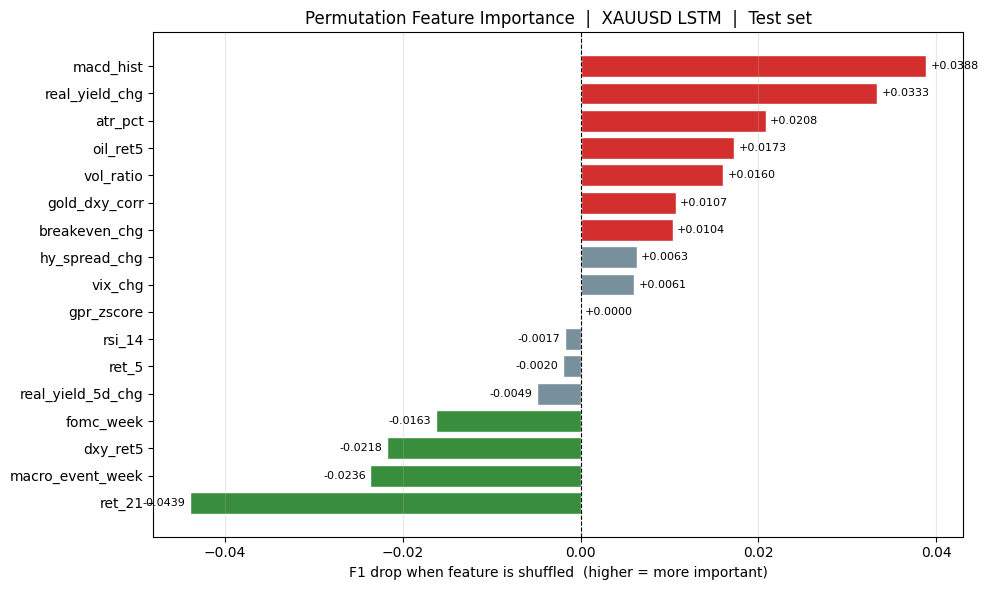


-- Colour guide --
  Red  (large +): model depends heavily on this feature  -> keep
  Gray (near  0): model barely uses this feature         -> safe to drop
  Green (negative): shuffling helps -> feature adds noise -> drop

Suggested KEEP (9): ['macd_hist', 'atr_pct', 'vol_ratio', 'vix_chg', 'oil_ret5', 'gold_dxy_corr', 'real_yield_chg', 'breakeven_chg', 'hy_spread_chg']
Suggested DROP (8): ['rsi_14', 'ret_5', 'ret_21', 'dxy_ret5', 'real_yield_5d_chg', 'fomc_week', 'macro_event_week', 'gpr_zscore']


In [76]:
# -- 14. FEATURE IMPORTANCE (Permutation) ------------------------------------
# For each feature: shuffle its values across the test sequences, run inference,
# and measure the drop in F1. Large drop = model relies on that feature.
# No extra libraries needed.

from sklearn.metrics import f1_score

N_REPEATS = 5   # average over N shuffles per feature to reduce noise

# Baseline F1 on unmodified test set
base_prob = model.predict(Xte_s, verbose=0).flatten()
base_pred = (base_prob >= 0.5).astype(int)
base_f1   = f1_score(yte_s, base_pred, zero_division=0)
print(f"Baseline F1: {base_f1:.4f}\n")
print(f"{'Feature':<25} {'F1 drop':>10}   {'Note'}")
print("-" * 55)

importances = {}
rng = np.random.default_rng(42)

for feat_idx, feat_name in enumerate(FEATURES):
    drops = []
    for _ in range(N_REPEATS):
        Xte_perm = Xte_s.copy()
        # Shuffle this feature across all samples; keep time-step axis intact
        shuf = rng.permutation(Xte_perm.shape[0])
        Xte_perm[:, :, feat_idx] = Xte_perm[shuf, :, feat_idx]
        perm_pred = (model.predict(Xte_perm, verbose=0).flatten() >= 0.5).astype(int)
        drops.append(base_f1 - f1_score(yte_s, perm_pred, zero_division=0))

    imp = float(np.mean(drops))
    importances[feat_name] = imp
    note = "*** important" if imp > 0.02 else ("-- noisy / drop" if imp < -0.005 else "")
    print(f"  {feat_name:<23} {imp:>+10.4f}   {note}")

# -- Plot --------------------------------------------------------------------
sorted_feats = sorted(importances, key=importances.get, reverse=True)
sorted_vals  = [importances[f] for f in sorted_feats]
colors       = ["#d32f2f" if v > 0.01 else "#388e3c" if v < -0.005 else "#78909c"
                for v in sorted_vals]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(sorted_feats[::-1], sorted_vals[::-1], color=colors[::-1], edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("F1 drop when feature is shuffled  (higher = more important)")
ax.set_title("Permutation Feature Importance  |  XAUUSD LSTM  |  Test set")
ax.grid(axis="x", alpha=0.3)
for i, (feat, val) in enumerate(zip(sorted_feats[::-1], sorted_vals[::-1])):
    ax.text(val + (0.0005 if val >= 0 else -0.0005),
            i, f"{val:+.4f}", va="center",
            ha="left" if val >= 0 else "right", fontsize=8)
plt.tight_layout()
plt.show()

# -- Summary -----------------------------------------------------------------
print("\n-- Colour guide --")
print("  Red  (large +): model depends heavily on this feature  -> keep")
print("  Gray (near  0): model barely uses this feature         -> safe to drop")
print("  Green (negative): shuffling helps -> feature adds noise -> drop")

keep = [f for f, v in importances.items() if v >  0.005]
drop = [f for f, v in importances.items() if v <= 0.005]
print(f"\nSuggested KEEP ({len(keep)}): {keep}")
print(f"Suggested DROP ({len(drop)}): {drop}")


Fold 1  train=2010-02-03–2018-02-03  val=2018-02-03–2019-02-03  test=2019-02-03–2020-02-03  acc=0.516  prec=0.543  rec=0.396  f1=0.458
Fold 2  train=2011-02-03–2019-02-03  val=2019-02-03–2020-02-03  test=2020-02-03–2021-02-03  acc=0.437  prec=0.457  rec=0.597  f1=0.518
Fold 3  train=2012-02-03–2020-02-03  val=2020-02-03–2021-02-03  test=2021-02-03–2022-02-03  acc=0.615  prec=0.623  rec=0.729  f1=0.672
Fold 4  train=2013-02-03–2021-02-03  val=2021-02-03–2022-02-03  test=2022-02-03–2023-02-03  acc=0.690  prec=0.584  rec=0.867  f1=0.698
Fold 5  train=2014-02-03–2022-02-03  val=2022-02-03–2023-02-03  test=2023-02-03–2024-02-03  acc=0.535  prec=0.480  rec=0.421  f1=0.449
Fold 6  train=2015-02-03–2023-02-03  val=2023-02-03–2024-02-03  test=2024-02-03–2025-02-03  acc=0.554  prec=0.717  rec=0.489  f1=0.581

  Walk-Forward Summary  (6 folds)
  Accuracy :  mean=0.5577  std=0.0791  min=0.4366  max=0.6897
  Precision:  mean=0.5674  std=0.0876  min=0.4574  max=0.7167
  Recall   :  mean=0.5830  std=

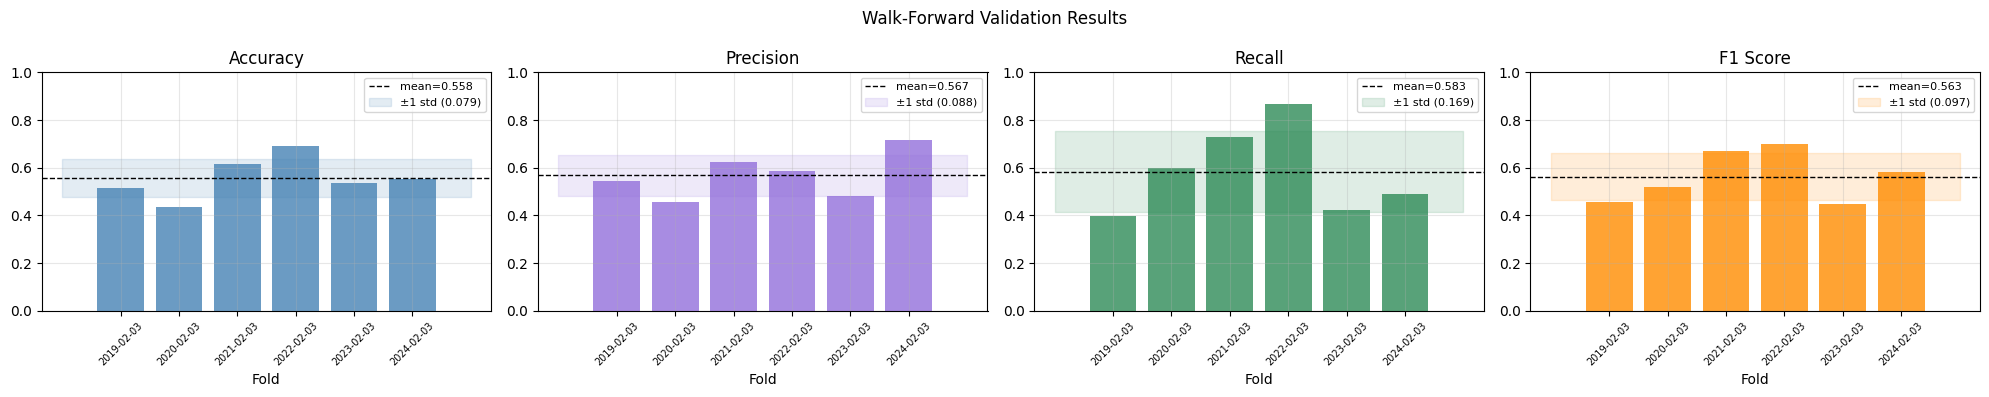

In [117]:
# -- 15. WALK-FORWARD VALIDATION ---------------------------------------------
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
import warnings

WF_TRAIN_YEARS = 8
WF_VAL_MONTHS  = 12
WF_TEST_MONTHS = 12
WF_EPOCHS      = 80
WF_BATCH       = 32

def build_and_train(Xtr, ytr, Xva, yva):
    cw = compute_class_weight("balanced", classes=np.array([0, 1]), y=ytr)
    m = models.Sequential([
        layers.Input(shape=(LOOKBACK, len(FEATURES))),
        layers.LSTM(24),
        layers.Dropout(0.4),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ])
    m.compile(optimizer=tf.keras.optimizers.Adam(5e-4),
              loss="binary_crossentropy", metrics=["accuracy"])
    m.fit(Xtr, ytr,
          validation_data=(Xva, yva),
          epochs=WF_EPOCHS, batch_size=WF_BATCH,
          class_weight={0: cw[0], 1: cw[1]},
          callbacks=[
              callbacks.EarlyStopping(monitor="val_loss", patience=10,
                                      restore_best_weights=True, verbose=0),
              callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                          patience=5, verbose=0),
          ], verbose=0)
    return m

fold_results = []
fold_boundaries = []

start_date = df_clean["Date"].min()
end_date   = df_clean["Date"].max()

fold_start = start_date
fold_num   = 0

while True:
    tr_end  = fold_start + pd.DateOffset(years=WF_TRAIN_YEARS)
    va_end  = tr_end     + pd.DateOffset(months=WF_VAL_MONTHS)
    te_end  = va_end     + pd.DateOffset(months=WF_TEST_MONTHS)

    if te_end > end_date:
        break

    tr = df_clean[(df_clean["Date"] >= fold_start) & (df_clean["Date"] <  tr_end)]
    va = df_clean[(df_clean["Date"] >= tr_end)     & (df_clean["Date"] <  va_end)]
    te = df_clean[(df_clean["Date"] >= va_end)     & (df_clean["Date"] <  te_end)]

    if len(tr) < LOOKBACK + 50 or len(va) < LOOKBACK + 10 or len(te) < LOOKBACK + 10:
        fold_start += pd.DateOffset(months=WF_TEST_MONTHS)
        continue

    sc_fold = StandardScaler()
    Xtr_ = sc_fold.fit_transform(tr[FEATURES])
    Xva_ = sc_fold.transform(va[FEATURES])
    Xte_ = sc_fold.transform(te[FEATURES])

    Xtr_s, ytr_s   = make_seq(Xtr_, tr["label"].astype(int).values, LOOKBACK)
    Xva_s, yva_s   = make_seq(Xva_, va["label"].astype(int).values, LOOKBACK)
    Xte_s_, yte_s_ = make_seq(Xte_, te["label"].astype(int).values, LOOKBACK)

    fold_num += 1
    print(f"Fold {fold_num}  train={fold_start.date()}–{tr_end.date()}  "
          f"val={tr_end.date()}–{va_end.date()}  "
          f"test={va_end.date()}–{te_end.date()}  ", end="")

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        m = build_and_train(Xtr_s, ytr_s, Xva_s, yva_s)

    prob_ = m.predict(Xte_s_, verbose=0).flatten()
    pred_ = (prob_ >= 0.5).astype(int)

    acc   = accuracy_score(yte_s_, pred_)
    prec  = precision_score(yte_s_, pred_, zero_division=0)
    rec   = recall_score(yte_s_, pred_, zero_division=0)
    f1    = f1_score(yte_s_, pred_, zero_division=0)

    print(f"acc={acc:.3f}  prec={prec:.3f}  rec={rec:.3f}  f1={f1:.3f}")

    fold_results.append({
        "fold":       fold_num,
        "test_start": va_end.date(),
        "test_end":   te_end.date(),
        "accuracy":   acc,
        "precision":  prec,
        "recall":     rec,
        "f1":         f1,
    })

    fold_start += pd.DateOffset(months=WF_TEST_MONTHS)

if not fold_results:
    print("Not enough data to run walk-forward folds. Try reducing WF_TRAIN_YEARS.")
else:
    results_df = pd.DataFrame(fold_results)

    accs  = results_df["accuracy"].values
    precs = results_df["precision"].values
    recs  = results_df["recall"].values
    f1s   = results_df["f1"].values

    print(f"\n{'='*50}")
    print(f"  Walk-Forward Summary  ({len(results_df)} folds)")
    print(f"{'='*50}")
    print(f"  Accuracy :  mean={accs.mean():.4f}  std={accs.std():.4f}  "
          f"min={accs.min():.4f}  max={accs.max():.4f}")
    print(f"  Precision:  mean={precs.mean():.4f}  std={precs.std():.4f}  "
          f"min={precs.min():.4f}  max={precs.max():.4f}")
    print(f"  Recall   :  mean={recs.mean():.4f}  std={recs.std():.4f}  "
          f"min={recs.min():.4f}  max={recs.max():.4f}")
    print(f"  F1       :  mean={f1s.mean():.4f}  std={f1s.std():.4f}  "
          f"min={f1s.min():.4f}  max={f1s.max():.4f}")

    print(f"\n  Low std = model is consistent across time periods.")
    print(f"  High std = performance depends heavily on the market regime.")

    # Plot — expanded to 4 subplots
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    fig.suptitle("Walk-Forward Validation Results", fontsize=12)

    for ax, metric, vals, color in [
        (axes[0], "Accuracy",  accs,  "steelblue"),
        (axes[1], "Precision", precs, "mediumpurple"),
        (axes[2], "Recall",    recs,  "seagreen"),
        (axes[3], "F1 Score",  f1s,   "darkorange"),
    ]:
        ax.bar(range(1, len(vals)+1), vals, color=color, alpha=0.8)
        ax.axhline(vals.mean(), color="black", linestyle="--", linewidth=1,
                   label=f"mean={vals.mean():.3f}")
        ax.fill_between([0, len(vals)+1],
                        vals.mean()-vals.std(), vals.mean()+vals.std(),
                        alpha=0.15, color=color, label=f"±1 std ({vals.std():.3f})")
        ax.set_title(metric)
        ax.set_xlabel("Fold")
        ax.set_xticks(range(1, len(vals)+1))
        ax.set_xticklabels([str(r["test_start"]) for r in fold_results],
                           rotation=45, fontsize=7)
        ax.legend(fontsize=8)
        ax.set_ylim(0, 1)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()